# BreaKHis Evaluation and Error Analysis

A single accuracy number does not tell me much about what the model is actually doing, so this notebook goes further than that. I want to see where it gets things right, where it goes wrong, and whether the probabilities mean anything useful or are just confident guesses.


In [1]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'src').exists() and (CWD / 'data').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'src').exists() and (CWD.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent
elif (CWD.parent.parent / 'src').exists() and (CWD.parent.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent.parent
else:
    raise RuntimeError(f'Could not resolve dissertation_project root from {CWD}')

REPO_ROOT = PROJECT_ROOT.parent
OUTPUTS = PROJECT_ROOT / 'outputs_v2'
FIGURES = OUTPUTS / 'figures'
METRICS = OUTPUTS / 'metrics'
REPORTS = OUTPUTS / 'reports'
MODELS = PROJECT_ROOT / 'models'
DATA_ROOT = PROJECT_ROOT / 'data' / 'dataset_cancer_v1' / 'dataset_cancer_v1'
WISCONSIN_ROOT = PROJECT_ROOT / 'notebook_Wisconsin'

for path in [FIGURES, METRICS, REPORTS]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)
print('Outputs:', OUTPUTS)

from PIL import Image
from IPython.display import display

from src.breakhis import build_binary_records, patient_level_split
from src.image_pipeline import build_resnet18, predict_dataframe, resolve_device
from src.metrics import classification_metrics, expected_calibration_error, save_calibration_plot, save_confusion_matrix, save_metric_barplot, save_roc_curve

df = build_binary_records(DATA_ROOT)
split = patient_level_split(df, random_state=SEED)
device = resolve_device()
model = build_resnet18(device, weights=None, checkpoint_path=MODELS / 'breakhis_resnet18_patient_level_clean.pth')
full_test_predictions = predict_dataframe(model, split.test.reset_index(drop=True), batch_size=16, device=device)
full_test_predictions.to_csv(REPORTS / 'breakhis_full_test_predictions.csv', index=False)
full_test_predictions.head()


Project root: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project
Outputs: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs_v2


,filepath,patient_id,label,magnification,y_true,y_pred,y_prob
0,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,SOB_B_F-14-21998CD,benign,100X,0,0,0.004601
1,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,SOB_B_F-14-21998CD,benign,100X,0,0,0.000018
2,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,SOB_B_F-14-21998CD,benign,100X,0,0,0.000085
3,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,SOB_B_F-14-21998CD,benign,100X,0,0,0.000006
4,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,SOB_B_F-14-21998CD,benign,100X,0,0,0.000021


In [2]:
image_metrics = classification_metrics(full_test_predictions['y_true'], full_test_predictions['y_pred'], full_test_predictions['y_prob'])
image_metrics['ece'] = expected_calibration_error(full_test_predictions['y_true'], full_test_predictions['y_prob'])
image_metrics_df = pd.DataFrame([image_metrics])
image_metrics_df.to_csv(METRICS / 'breakhis_image_level_metrics.csv', index=False)
image_metrics_df


,accuracy,precision,recall,f1_score,roc_auc,brier_score,ece
0,0.770037,0.757344,0.835211,0.794374,0.851419,0.197075,0.173434


In [3]:
patient_predictions = (
    full_test_predictions.groupby(['patient_id', 'label'])['y_prob']
    .mean()
    .reset_index()
)
patient_predictions['y_true'] = (patient_predictions['label'] == 'malignant').astype(int)
patient_predictions['y_pred'] = (patient_predictions['y_prob'] >= 0.5).astype(int)
patient_metrics = classification_metrics(patient_predictions['y_true'], patient_predictions['y_pred'], patient_predictions['y_prob'])
patient_metrics['ece'] = expected_calibration_error(patient_predictions['y_true'], patient_predictions['y_prob'])
patient_metrics_df = pd.DataFrame([patient_metrics])
patient_metrics_df.to_csv(METRICS / 'breakhis_patient_level_metrics.csv', index=False)
patient_predictions.to_csv(REPORTS / 'breakhis_patient_level_predictions.csv', index=False)
patient_metrics_df


,accuracy,precision,recall,f1_score,roc_auc,brier_score,ece
0,0.769231,0.875,0.777778,0.823529,0.888889,0.149788,0.234854


In [4]:
magnification_metrics = []
for magnification, frame in full_test_predictions.groupby('magnification'):
    metrics = classification_metrics(frame['y_true'], frame['y_pred'], frame['y_prob'])
    metrics['magnification'] = magnification
    magnification_metrics.append(metrics)
magnification_metrics_df = pd.DataFrame(magnification_metrics).sort_values('magnification')
magnification_metrics_df.to_csv(METRICS / 'breakhis_magnification_metrics.csv', index=False)
magnification_metrics_df


,accuracy,precision,recall,f1_score,roc_auc,brier_score,magnification
0,0.743590,0.729858,0.823529,0.773869,0.852582,0.208448,100X
1,0.797015,0.796875,0.840659,0.818182,0.880090,0.178247,200X
2,0.801325,0.776536,0.874214,0.822485,0.865286,0.180798,400X
3,0.743516,0.731343,0.807692,0.767624,0.811122,0.217914,40X


In [5]:
save_confusion_matrix(patient_predictions['y_true'], patient_predictions['y_pred'], ['benign', 'malignant'], FIGURES / 'breakhis_patient_confusion_matrix.png', 'Patient-level confusion matrix')
save_roc_curve(patient_predictions['y_true'], patient_predictions['y_prob'], FIGURES / 'breakhis_patient_roc_curve.png', 'Patient-level ROC curve')
save_calibration_plot(patient_predictions['y_true'], patient_predictions['y_prob'], FIGURES / 'breakhis_patient_calibration.png', 'Patient-level calibration curve')
save_metric_barplot(
    magnification_metrics_df[['magnification', 'roc_auc']],
    x='magnification',
    y='roc_auc',
    hue=None,
    output_path=FIGURES / 'breakhis_magnification_roc_auc.png',
    title='ROC-AUC by magnification on the corrected test set',
    ylabel='ROC-AUC',
)


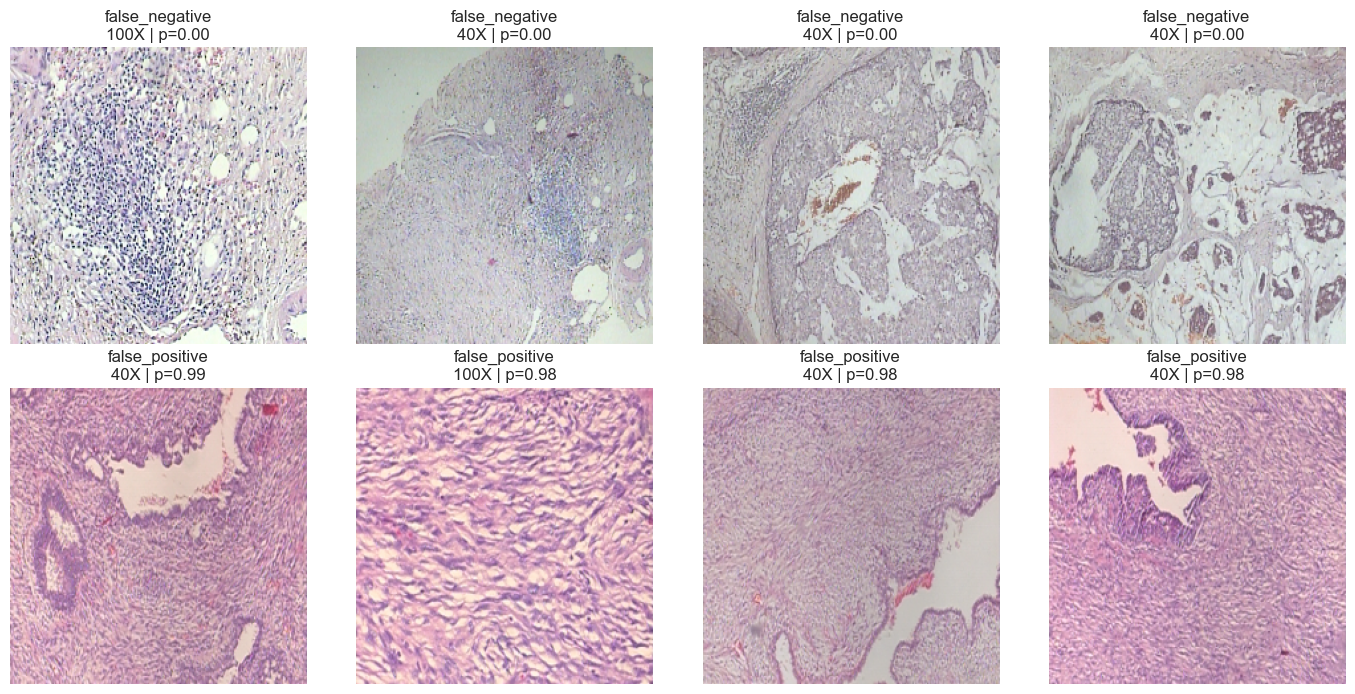

In [6]:
false_negatives = full_test_predictions[(full_test_predictions['y_true'] == 1) & (full_test_predictions['y_pred'] == 0)].sort_values('y_prob').head(4)
false_positives = full_test_predictions[(full_test_predictions['y_true'] == 0) & (full_test_predictions['y_pred'] == 1)].sort_values('y_prob', ascending=False).head(4)
error_panel = pd.concat([false_negatives.assign(error_type='false_negative'), false_positives.assign(error_type='false_positive')], ignore_index=True)
error_panel.to_csv(REPORTS / 'breakhis_error_examples.csv', index=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, (_, row) in zip(axes.ravel(), error_panel.iterrows()):
    with Image.open(row['filepath']) as image:
        ax.imshow(image.convert('RGB'))
    ax.set_title(f"{row['error_type']}\n{row['magnification']} | p={row['y_prob']:.2f}")
    ax.axis('off')
fig.tight_layout()
fig.savefig(FIGURES / 'breakhis_error_panel.png', dpi=300)
plt.show()


## What I take from this

This holdout evaluation is the main image result I will quote in the write-up. It is lower than the image-level result I started with, and that is fine because the split is now doing the job I actually wanted it to do. What matters most here is not just the final accuracy but the magnification breakdown, the calibration view, and the concrete failure cases. Those give me something real to discuss later instead of repeating a single score in slightly different formats.
